In [2]:
import numpy as np
import matplotlib.pyplot as plt
from reconstruction_comparison import *
from corner import corner


%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
fname = "/mnt/users/rstiskalek/csiborgtools/scripts/flow/test_samples.hdf5"

samples = get_some_samples(fname, ["aFP", "bFP", "cFP", "scatter", "Vext"])

data, labels, __ = samples_for_corner(samples)

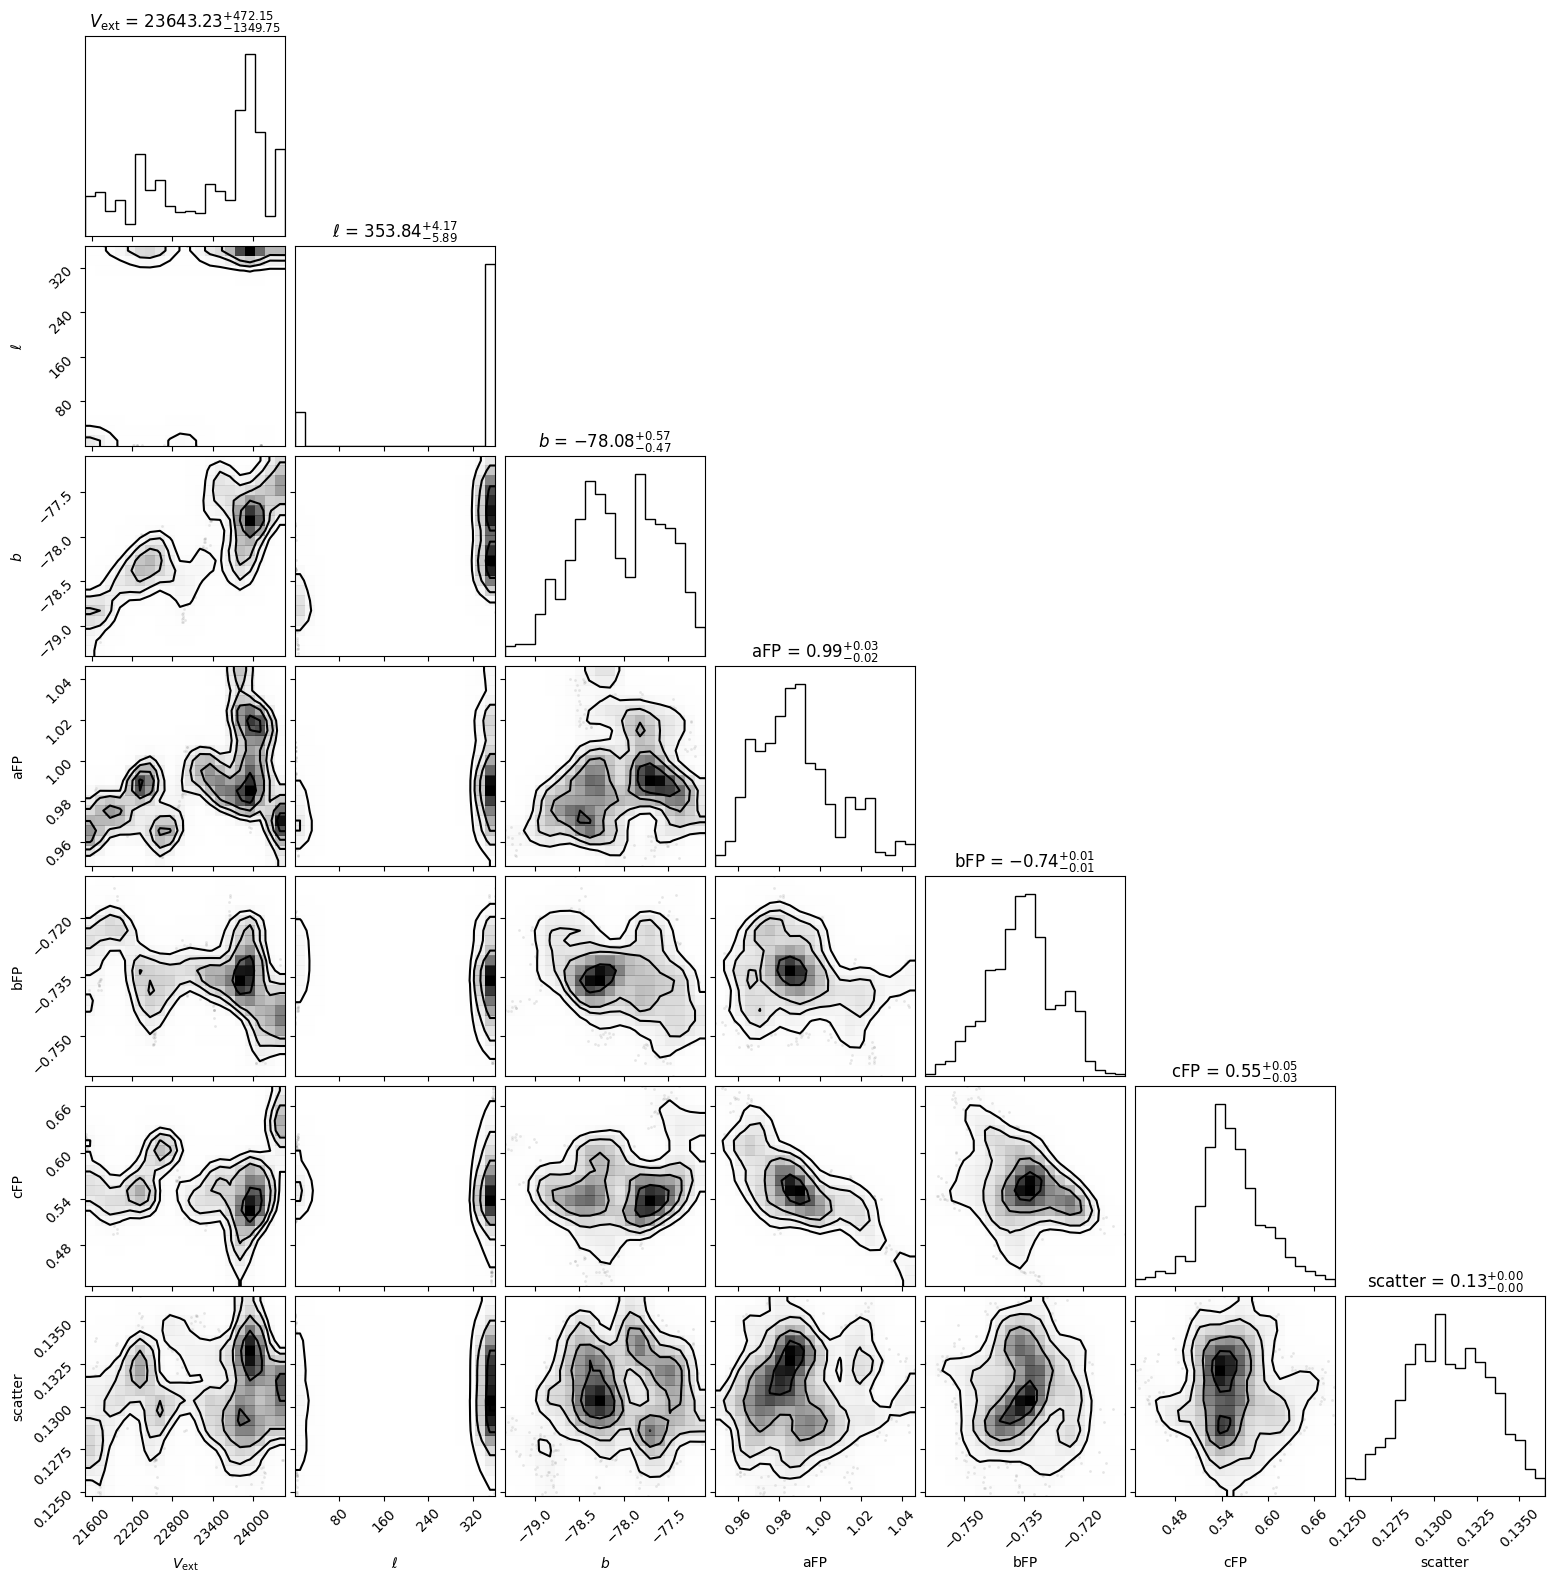

In [36]:
fig = corner(data, labels=labels, show_titles=True, smooth=1)
fig.savefig("../../plots/FP_corner.png")
fig.show()

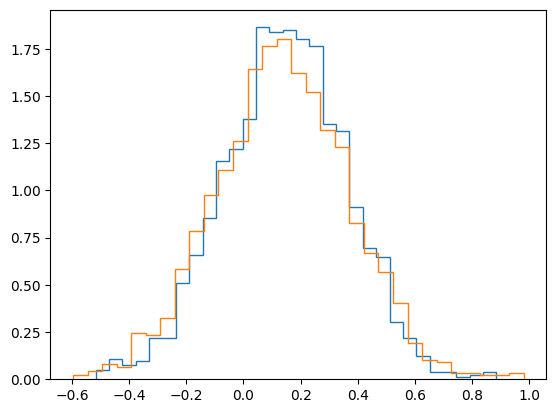

In [ ]:
with File(fname, 'r') as f:
    i = f["data/i"][...]
    s = f["data/s"][...]
    r = f["data/r"][...]
    
    theta = f["data/theta"][...]
    phi = f["data/phi"][...]


rpred = s[:, None] * samples["aFP"][None, :] + i[:, None] * samples["bFP"][None, :] + samples["cFP"][None, :]

plt.figure()
plt.hist(np.mean(rpred, axis=1), bins="auto", histtype="step", label="Predicted", density=1)
plt.hist(r, bins="auto", histtype="step", label="True", density=1)

plt.show()

o

In [43]:
with File(fname, 'r') as f:
    dist = f["samples/r"][...]

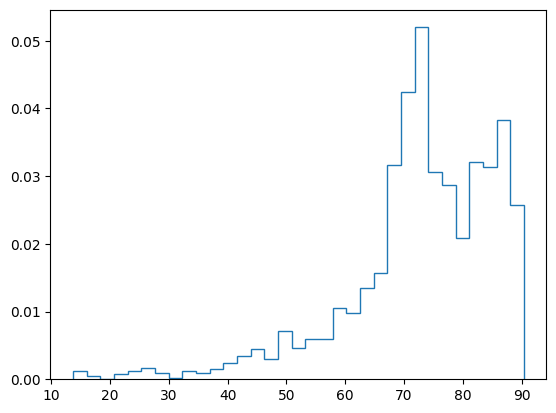

In [44]:
plt.figure()
plt.hist(np.mean(dist, axis=0), bins="auto", histtype="step", label="True", density=1)
plt.show()

In [61]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.3)
cosmo.comoving_distance(0.1)

<Quantity 292.91814134 Mpc>

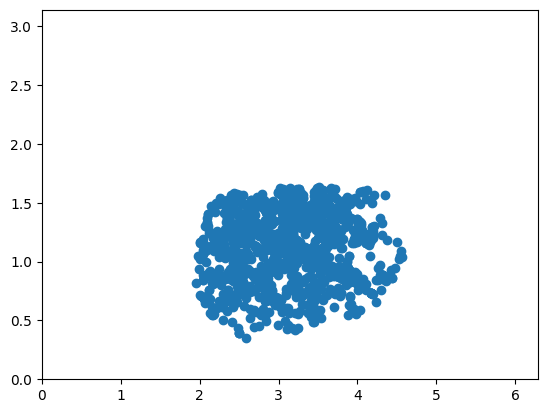

In [32]:
plt.figure()
plt.scatter(phi, theta)

plt.xlim(0, 2*np.pi)
plt.ylim(0, np.pi)

plt.show()

In [58]:
def r2distmod(r, Om0):
    return (-0.000009) + (1.0 * (
        ((2.171392 - (0.000005 * r)) *
         ((jnp.log(0.556252 * r)) - ((-0.007872) * r) - (9.911776 * Om0)) -
         (-26.274343)) +
        ((-0.016363 * r) + (21.519941 * Om0))
    ))
    
    
with File(fname, 'r') as f:
    r = f["samples/r"][...]
    rmag = f["data/rmag"][...]



mu = r2distmod(r, 0.3)
mu = np.mean(mu, axis=0)


M = rmag - mu

In [59]:
# M_wMalmquist = rmag - mu

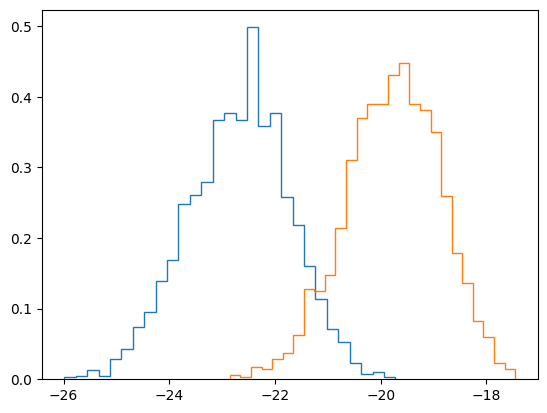

In [60]:
plt.figure()
plt.hist(M_wMalmquist, bins="auto", histtype="step", label="Malmquist", density=1)
plt.hist(M, bins="auto", histtype="step", label="Without", density=1)

plt.show()
plt.show()